In [1]:
#%%
import cellpose.core
import time, os, sys
from urllib.parse import urlparse
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
mpl.rcParams['figure.dpi'] = 300
from cellpose import utils, io
from cellpose import models, io
import cellpose
import pandas as pd
import numpy as np
from skimage.io import imread
import scipy as sp
from cellpose import plot
from scipy.signal import savgol_filter
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from skimage.segmentation import find_boundaries
from skimage.filters import threshold_local
import imageio


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, matthews_corrcoef

plt.rcParams["figure.figsize"] = (3,3)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline



In [2]:
cellpose.core.use_gpu()

True

In [3]:
data_directory='/n/boslfs02/LABS/murray_lab/Users/pnanda/DCS/Manuscript/eDCS007_FBP_pACT1_mNeptune/'
save_directory='/n/home01/pnandabbs/DCS/Manuscript/Figure1/Figure1B_FBP_heterogeneity/'

In [4]:
model = models.CellposeModel(gpu=True, model_type='cyto2')
chan = [[0,0]]

model_type argument is not used in v4.0.1+. Ignoring this argument...


In [5]:
files=os.listdir(data_directory)

# 2% Glucose

model_type argument is not used in v4.0.1+. Ignoring this argument...


Arr mean 1.9826955174775764
Rec mean 1.550470138009571
Arr mean 0.3183164810250105
Rec mean 0.33494564528605936


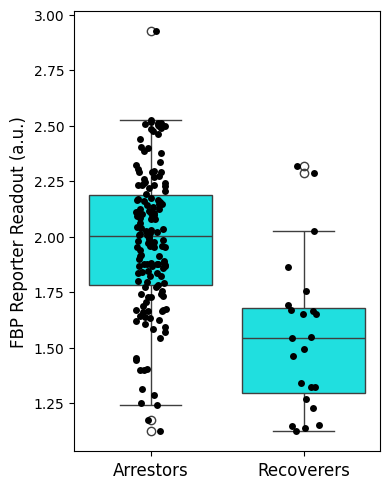

In [7]:
model = models.CellposeModel(gpu=True, model_type='cyto2')
chan = [[0,0]]

arr_vals=[]
rec_vals=[]

for s in [1,2,3,5]:
    img_stack_mcherry=[]
    img_stack_yfp=[]

    file_loc=data_directory+"yPN2_w1Brightfield confocal_s"+str(s)+"_t"+str(7)+".TIF"
    img_stack_bf=imread(file_loc).astype('int16')
    
    
    file_loc_mcherry=data_directory+"yPN2_w2594 laser 20_s"+str(s)+"_t"+str(7)+".TIF"
    img_stack_mcherry=imread(file_loc_mcherry).astype('int16').max(axis=2)


    file_loc_yfp=data_directory+"yPN2_w3515 laser 30_s"+str(s)+"_t"+str(7)+".TIF"
    img_stack_yfp=imread(file_loc_yfp).astype('int16').max(axis=2)
    
    labels=imread(save_directory+'Annotations/'+'Labels'+str(s)+'.tif')[7,:,:]
    
    masks_zero, flows, diams = model.eval(img_stack_bf, diameter=50)
        
  # Get coordinates where labels exist (non-zero)
    label_coords = np.where(labels > 0)
    label_values = labels[label_coords]

    # For each label pixel, find which mask it belongs to
    mask_values_at_labels = masks_zero[label_coords]

    # Create mapping
    df = pd.DataFrame({
        'mask_id': mask_values_at_labels,
        'label': label_values
    })

    # Remove background masks (mask_id == 0)
    df = df[df['mask_id'] > 0]

    # Get one label per mask (most common)
    df = df.groupby('mask_id')['label'].agg(lambda x: x.mode()[0]).reset_index()

    gfp_vals=[]
    for m in df['mask_id']:
        gfp_vals.append((img_stack_yfp[(masks_zero==m)].mean()-img_stack_yfp[(masks_zero==0)].mean())
                        /(img_stack_mcherry[(masks_zero==m)].mean()-img_stack_mcherry[(masks_zero==0)].mean()))
    df['Mean_GFP']=gfp_vals
    
    arr_vals.extend(df.loc[df['label']==1,'Mean_GFP'].tolist())
    rec_vals.extend(df.loc[df['label']==2,'Mean_GFP'].tolist())

full=arr_vals+rec_vals

rec_vals=np.array(rec_vals)[~np.isnan(rec_vals)]
arr_vals=np.array(arr_vals)[~np.isnan(arr_vals)]

print("Arr mean",np.nanmean(arr_vals))
print("Rec mean",np.nanmean(rec_vals))

print("Arr mean",np.nanstd(arr_vals))
print("Rec mean",np.nanstd(rec_vals))


plt.figure(figsize=(4,5))
sns.boxplot(data=[arr_vals,rec_vals],color='cyan')
sns.stripplot(data=[arr_vals,rec_vals],color='k')
plt.ylabel('FBP Reporter Readout (a.u.)',fontsize=12)
plt.xticks([0,1],["Arrestors","Recoverers"],fontsize=12)
# plt.ylim([0,100])
plt.tight_layout()
plt.savefig('D100_FBP.png',dpi=300)


/tmp/ipykernel_1094860/964221508.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1094860/964221508.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1094860/964221508.py:83: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


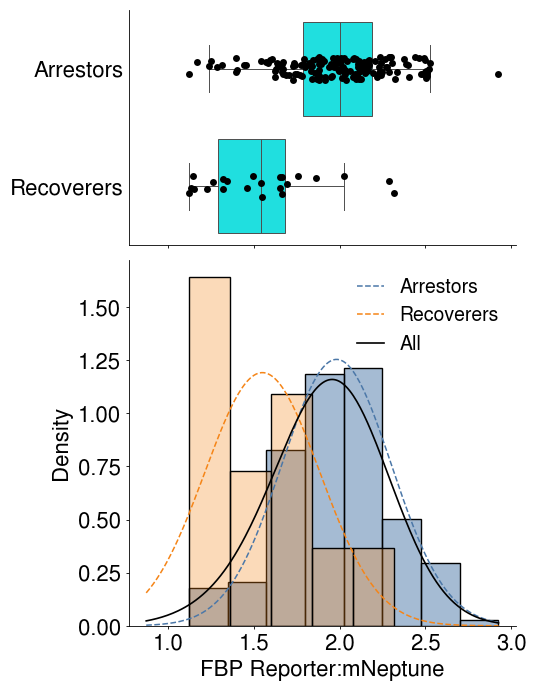

In [8]:
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- Fit Gaussians ----------------
mu_arr, std_arr = stats.norm.fit(arr_vals)
mu_rec, std_rec = stats.norm.fit(rec_vals)

w_arr = len(arr_vals) / (len(arr_vals) + len(rec_vals))
w_rec = 1 - w_arr

x = np.linspace(min(arr_vals.min(), rec_vals.min()-0.25) ,
                max(arr_vals.max(), rec_vals.max()-0.25), 200)

pdf_arr = stats.norm.pdf(x, mu_arr, std_arr)
pdf_rec = stats.norm.pdf(x, mu_rec, std_rec)
pdf_mix = w_arr * pdf_arr + w_rec * pdf_rec

# ---------------- Aesthetics ----------------
plt.rcParams['font.sans-serif'] = ['Nimbus Sans']
plt.rcParams['font.size'] = 16
plt.rcParams['axes.linewidth'] = 0.6

arr_color = "#4C78A8"   # blue
rec_color = "#F58518"   # orange

# ---------------- Data frame ----------------
df_long = pd.DataFrame({
    "sfGFPmt": np.concatenate([arr_vals, rec_vals]),
    "State": (["Arrestors"] * len(arr_vals)) + (["Recoverers"] * len(rec_vals)),
})

bins_arr = np.histogram_bin_edges(arr_vals, bins=8)
bins_rec = np.histogram_bin_edges(rec_vals, bins=5)

# ---------------- Figure ----------------
fig = plt.figure(figsize=(5.0, 8.0), constrained_layout=True)
gs = fig.add_gridspec(2, 1, height_ratios=[0.9, 1.4], hspace=0.05)

# Top: box + strip
ax_box = fig.add_subplot(gs[0, 0])
sns.boxplot(
    data=df_long, x="sfGFPmt", y="State",
    order=["Arrestors", "Recoverers"],
    orient="h", ax=ax_box, showfliers=False,
    palette=['cyan', 'cyan'],
    linewidth=0.7
)
sns.stripplot(
    data=df_long, x="sfGFPmt", y="State",
    order=["Arrestors", "Recoverers"],
    orient="h", ax=ax_box, color="k", size=5, alpha=1
)
ax_box.set_xlabel("")
ax_box.set_ylabel("")
ax_box.tick_params(axis="x", labelbottom=False, length=2, width=0.6)
ax_box.tick_params(axis="y", length=0, width=0.6)

# Bottom: hist + PDFs + mixture
ax_dist = fig.add_subplot(gs[1, 0], sharex=ax_box)

sns.histplot(
    arr_vals, bins=bins_arr, stat="density",
    color=arr_color, alpha=0.5, edgecolor="k", ax=ax_dist
)
sns.histplot(
    rec_vals, bins=bins_rec, stat="density",
    color=rec_color, alpha=0.3, edgecolor="k", ax=ax_dist
)

ax_dist.plot(x, pdf_arr, "--", linewidth=1.1, color=arr_color, label="Arrestors")
ax_dist.plot(x, pdf_rec, "--", linewidth=1.1, color=rec_color, label="Recoverers")
ax_dist.plot(x, pdf_mix, "-",  linewidth=1.2, color="k",        label="All")

ax_dist.set_xlabel(r"FBP Reporter:mNeptune")
ax_dist.set_ylabel("Density")
ax_dist.tick_params(length=2, width=0.6)
ax_dist.legend(frameon=False, fontsize=14, handlelength=1.4,loc='upper right')

sns.despine(fig)
plt.tight_layout()

# High‑res, vector‑friendly save (adjust path as needed)
# fig.savefig(save_directory + "mtsfGFP_box_hist_mixture.pdf")
fig.savefig("Figure1B_FBP_heterogeneityD2.png", dpi=300, bbox_inches="tight")

F1: 0.0
MCC: 0.0


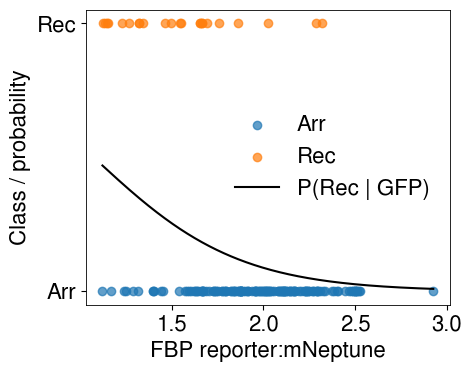

In [9]:
X = np.concatenate([arr_vals, rec_vals])[:, None]   # shape (n_samples, 1)
y = np.concatenate([
    np.zeros(arr_vals.shape[0], dtype=int),
    np.ones(rec_vals.shape[0], dtype=int)
])  # shape (n_samples,)

clf = LogisticRegression(max_iter=1000, solver='lbfgs')
clf.fit(X, y)

y_pred = clf.predict(X)

f1 = f1_score(y, y_pred)
mcc = matthews_corrcoef(y, y_pred)

print("F1:", f1)
print("MCC:", mcc)

x_grid = np.linspace(X.min(), X.max(), 500)[:, None]
p_grid = clf.predict_proba(x_grid)[:, 1]  # P(recovering | GFP)

plt.figure(figsize=(5, 4))

# real points, jittered vertically for visibility
plt.scatter(arr_vals, np.zeros_like(arr_vals),
            color='tab:blue', label='Arr', alpha=0.7)
plt.scatter(rec_vals, np.ones_like(rec_vals),
            color='tab:orange', label='Rec', alpha=0.7)

# logistic regression probability curve
plt.plot(x_grid.ravel(), p_grid, color='k', label='P(Rec | GFP)')

plt.yticks([0, 1], ['Arr', 'Rec'])
plt.xlabel(r"FBP reporter:mNeptune")
plt.ylabel('Class / probability')
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(save_directory + "fbp005_logistic.png", dpi=300, bbox_inches="tight")


# 0.05% Glucose

model_type argument is not used in v4.0.1+. Ignoring this argument...


Arr mean 1.3906788802829437
Rec mean 0.6989732237930946
Arr mean 0.27954860817268073
Rec mean 0.2624482296721799


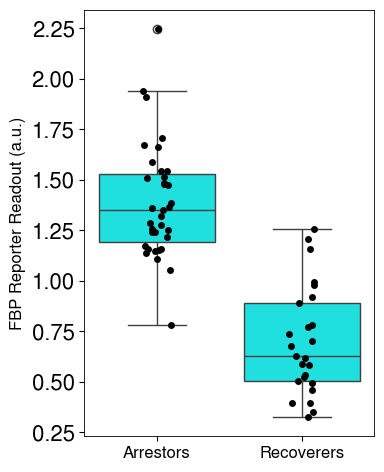

In [12]:
model = models.CellposeModel(gpu=True, model_type='cyto2')
chan = [[0,0]]

arr_vals=[]
rec_vals=[]

for s in [18,19]:
    img_stack_mcherry=[]
    img_stack_yfp=[]

    file_loc=data_directory+"yPN2_w1Brightfield confocal_s"+str(s)+"_t"+str(7)+".TIF"
    img_stack_bf=imread(file_loc).astype('int16')
    
    
    file_loc_mcherry=data_directory+"yPN2_w2594 laser 20_s"+str(s)+"_t"+str(7)+".TIF"
    img_stack_mcherry=imread(file_loc_mcherry).astype('int16').max(axis=2)


    file_loc_yfp=data_directory+"yPN2_w3515 laser 30_s"+str(s)+"_t"+str(7)+".TIF"
    img_stack_yfp=imread(file_loc_yfp).astype('int16').max(axis=2)
    
    labels=imread(save_directory+'Annotations/'+'Labels'+str(s)+'.tif')[7,:,:]
    
    masks_zero, flows, diams = model.eval(img_stack_bf, diameter=50)
        
  # Get coordinates where labels exist (non-zero)
    label_coords = np.where(labels > 0)
    label_values = labels[label_coords]

    # For each label pixel, find which mask it belongs to
    mask_values_at_labels = masks_zero[label_coords]

    # Create mapping
    df = pd.DataFrame({
        'mask_id': mask_values_at_labels,
        'label': label_values
    })

    # Remove background masks (mask_id == 0)
    df = df[df['mask_id'] > 0]

    # Get one label per mask (most common)
    df = df.groupby('mask_id')['label'].agg(lambda x: x.mode()[0]).reset_index()

    gfp_vals=[]
    for m in df['mask_id']:
        gfp_vals.append((img_stack_yfp[(masks_zero==m)].mean()-img_stack_yfp[(masks_zero==0)].mean())
                        /(img_stack_mcherry[(masks_zero==m)].mean()-img_stack_mcherry[(masks_zero==0)].mean()))

    df['Mean_GFP']=gfp_vals
    
    arr_vals.extend(df.loc[df['label']==1,'Mean_GFP'].tolist())
    rec_vals.extend(df.loc[df['label']==2,'Mean_GFP'].tolist())


full=arr_vals+rec_vals

rec_vals=np.array(rec_vals)[~np.isnan(rec_vals)]
arr_vals=np.array(arr_vals)[~np.isnan(arr_vals)]

print("Arr mean",np.nanmean(arr_vals))
print("Rec mean",np.nanmean(rec_vals))

print("Arr mean",np.nanstd(arr_vals))
print("Rec mean",np.nanstd(rec_vals))


plt.figure(figsize=(4,5))
sns.boxplot(data=[arr_vals,rec_vals],color='cyan')
sns.stripplot(data=[arr_vals,rec_vals],color='k')
plt.ylabel('FBP Reporter Readout (a.u.)',fontsize=12)
plt.xticks([0,1],["Arrestors","Recoverers"],fontsize=12)
# plt.ylim([0,100])
plt.tight_layout()
plt.savefig('D10_FBP.png',dpi=300)


/tmp/ipykernel_1094860/2655985315.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1094860/2655985315.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1094860/2655985315.py:86: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found beca

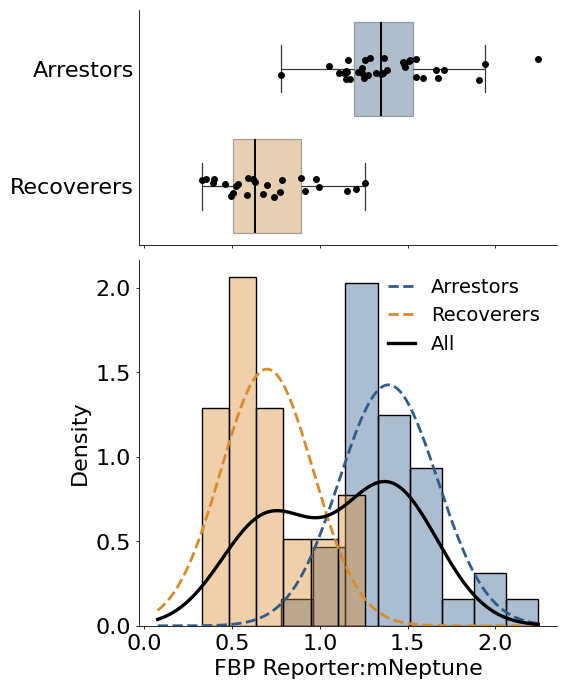

In [14]:
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- Fit Gaussians ----------------
mu_arr, std_arr = stats.norm.fit(arr_vals)
mu_rec, std_rec = stats.norm.fit(rec_vals)

w_arr = len(arr_vals) / (len(arr_vals) + len(rec_vals))
w_rec = 1 - w_arr

x = np.linspace(min(arr_vals.min(), rec_vals.min()-0.25),
                max(arr_vals.max(), rec_vals.max()-0.25), 200)

pdf_arr = stats.norm.pdf(x, mu_arr, std_arr)
pdf_rec = stats.norm.pdf(x, mu_rec, std_rec)
pdf_mix = w_arr * pdf_arr + w_rec * pdf_rec

# ---------------- Aesthetics ----------------
plt.rcParams['font.sans-serif'] = ['Nimbus Sans']
plt.rcParams['font.size'] = 16
plt.rcParams['axes.linewidth'] = 0.6

arr_color  = "#2F5C8A"   # denim
rec_color  = "#D98A2B"   # amber
fill_alpha = 0.4         # one alpha for every fill: both groups, box + histogram

# ---------------- Data frame ----------------
df_long = pd.DataFrame({
    "sfGFPmt": np.concatenate([arr_vals, rec_vals]),
    "State": (["Arrestors"] * len(arr_vals)) + (["Recoverers"] * len(rec_vals)),
})

bins_arr = np.histogram_bin_edges(arr_vals, bins=8)
bins_rec = np.histogram_bin_edges(rec_vals, bins=6)

# ---------------- Figure ----------------
fig = plt.figure(figsize=(5.4, 8.0), constrained_layout=True)
gs = fig.add_gridspec(2, 1, height_ratios=[0.9, 1.4], hspace=0.05)

# Top: box + strip
ax_box = fig.add_subplot(gs[0, 0])
sns.boxplot(
    data=df_long, x="sfGFPmt", y="State",
    order=["Arrestors", "Recoverers"],
    orient="h", ax=ax_box, showfliers=False,
    palette=[arr_color, rec_color],
    linewidth=0.9,
    boxprops=dict(alpha=fill_alpha),
    medianprops=dict(color="k", linewidth=1.4),
)
sns.stripplot(
    data=df_long, x="sfGFPmt", y="State",
    order=["Arrestors", "Recoverers"],
    orient="h", ax=ax_box, color="k", size=5, alpha=1
)
ax_box.set_xlabel("")
ax_box.set_ylabel("")
ax_box.tick_params(axis="x", labelbottom=False, length=2, width=0.6)
ax_box.tick_params(axis="y", length=0, width=0.6)

# Bottom: hist + PDFs + mixture
ax_dist = fig.add_subplot(gs[1, 0], sharex=ax_box)

sns.histplot(
    arr_vals, bins=bins_arr, stat="density",
    color=arr_color, alpha=fill_alpha, edgecolor="k", ax=ax_dist
)
sns.histplot(
    rec_vals, bins=bins_rec, stat="density",
    color=rec_color, alpha=fill_alpha, edgecolor="k", ax=ax_dist
)

ax_dist.plot(x, pdf_arr, "--", linewidth=2, color=arr_color, label="Arrestors")
ax_dist.plot(x, pdf_rec, "--", linewidth=2, color=rec_color, label="Recoverers")
ax_dist.plot(x, pdf_mix, "-",  linewidth=2.4, color="k",        label="All")

ax_dist.set_xlabel(r"FBP Reporter:mNeptune")
ax_dist.set_ylabel("Density")
ax_dist.tick_params(length=2, width=0.6)
ax_dist.legend(frameon=False, fontsize=14, handlelength=1.4, loc='best')

sns.despine(fig)
plt.tight_layout()
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']  # exists on Mac, Illustrator knows it

# High-res, vector-friendly save (adjust path as needed)
# fig.savefig(save_directory + "mtsfGFP_box_hist_mixture.pdf")
fig.savefig("Figure1B_FBP_heterogeneityD005.svg", format="svg",dpi=1200)